## Étape 0 — Installation des bibliothèques
Lance cette cellule **une seule fois** si les packages ne sont pas encore installés.



In [ ]:
# Décommente et lance si nécessaire
# !pip install numpy pandas scikit-learn matplotlib seaborn

## Étape 1 — Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

print('✅ Bibliothèques importées avec succès !')

✅ Bibliothèques importées avec succès !


## Étape 2 — Chargement des données
> Place le fichier `sonar_all-data.csv` dans le **même dossier** que ce notebook.

In [ ]:
# Noms des colonnes : 60 fréquences + 1 label
colonnes = [f"freq_{i}" for i in range(1, 61)] + ["label"]

df = pd.read_csv("sonar_all-data.csv", header=None, names=colonnes)

print(f"Dimensions     : {df.shape}")
print(f"Classes        : {df['label'].value_counts().to_dict()}")
print(f"Valeurs nulles : {df.isnull().sum().sum()}")
df.head()

Dimensions     : (208, 61)
Classes        : {'M': 111, 'R': 97}
Valeurs nulles : 0


,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,freq_8,freq_9,freq_10,...,freq_52,freq_53,freq_54,freq_55,freq_56,freq_57,freq_58,freq_59,freq_60,label
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


##Étape 3 — Exploration des données (EDA)

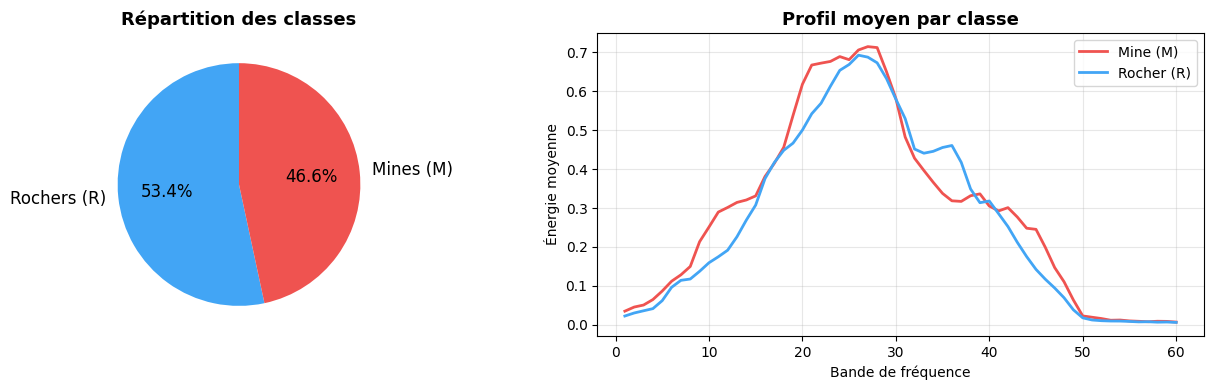

In [3]:
# Distribution des classes
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie chart
counts = df['label'].value_counts()
axes[0].pie(counts, labels=['Rochers (R)', 'Mines (M)'],
            autopct='%1.1f%%', colors=['#42A5F5', '#EF5350'],
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Répartition des classes', fontsize=13, fontweight='bold')

# Moyenne des features par classe
mines  = df[df['label'] == 'M'].drop('label', axis=1).mean()
rochers = df[df['label'] == 'R'].drop('label', axis=1).mean()
x = range(1, 61)
axes[1].plot(x, mines,   label='Mine (M)',   color='#EF5350', linewidth=2)
axes[1].plot(x, rochers, label='Rocher (R)', color='#42A5F5', linewidth=2)
axes[1].set_xlabel('Bande de fréquence')
axes[1].set_ylabel('Énergie moyenne')
axes[1].set_title('Profil moyen par classe', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Statistiques descriptives
df.describe().round(3)

,freq_1,freq_2,freq_3,freq_4,freq_5,freq_6,freq_7,freq_8,freq_9,freq_10,...,freq_51,freq_52,freq_53,freq_54,freq_55,freq_56,freq_57,freq_58,freq_59,freq_60
count,208.000,208.000,208.000,208.000,208.000,208.000,208.000,208.000,208.000,208.000,...,208.000,208.000,208.000,208.000,208.000,208.000,208.000,208.000,208.000,208.000
mean,0.029,0.038,0.044,0.054,0.075,0.105,0.122,0.135,0.178,0.208,...,0.016,0.013,0.011,0.011,0.009,0.008,0.008,0.008,0.008,0.007
std,0.023,0.033,0.038,0.047,0.056,0.059,0.062,0.085,0.118,0.134,...,0.012,0.010,0.007,0.007,0.007,0.006,0.006,0.006,0.006,0.005
min,0.002,0.001,0.002,0.006,0.007,0.010,0.003,0.006,0.008,0.011,...,0.000,0.001,0.000,0.001,0.001,0.000,0.000,0.000,0.000,0.001
25%,0.013,0.016,0.019,0.024,0.038,0.067,0.081,0.080,0.097,0.111,...,0.008,0.007,0.005,0.005,0.004,0.004,0.004,0.004,0.004,0.003
50%,0.023,0.031,0.034,0.044,0.062,0.092,0.107,0.112,0.152,0.182,...,0.014,0.011,0.010,0.009,0.008,0.007,0.006,0.006,0.006,0.005
75%,0.036,0.048,0.058,0.064,0.100,0.134,0.154,0.170,0.233,0.269,...,0.021,0.017,0.015,0.014,0.012,0.011,0.010,0.010,0.010,0.009
max,0.137,0.234,0.306,0.426,0.401,0.382,0.373,0.459,0.683,0.711,...,0.100,0.071,0.039,0.035,0.045,0.039,0.036,0.044,0.036,0.044


## Étape 4 — Préparation des données

In [5]:
X = df.drop('label', axis=1).values           # Features (60 colonnes)
y = (df['label'] == 'M').astype(int).values   # 1 = Mine, 0 = Rocher

# Séparation entraînement / test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation (important pour MLP et KNN)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Entraînement : {X_train.shape[0]} échantillons")
print(f"Test         : {X_test.shape[0]} échantillons")
print(f"Features     : {X_train.shape[1]}")

Entraînement : 166 échantillons
Test         : 42 échantillons
Features     : 60


##  Étape 5 — Entraînement des modèles

In [6]:
modeles = {
    "Réseau de neurones (MLP)": MLPClassifier(
        hidden_layer_sizes=(24,), max_iter=1000, random_state=42
    ),
    "K plus proches voisins":   KNeighborsClassifier(n_neighbors=5),
    "Random Forest":            RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":                      SVC(kernel='rbf', random_state=42),
}

resultats = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    resultats[nom] = {'acc': acc, 'y_pred': y_pred}
    print(f"✅ {nom:<35} Précision : {acc*100:.1f}%")

✅ Réseau de neurones (MLP)            Précision : 88.1%
✅ K plus proches voisins              Précision : 78.6%
✅ Random Forest                       Précision : 81.0%
✅ SVM                                 Précision : 92.9%


## Étape 6 — Rapport de classification détaillé

In [7]:
for nom, res in resultats.items():
    print(f"\n{'='*55}")
    print(f"  {nom}")
    print(f"{'='*55}")
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Rocher (R)', 'Mine (M)']
    ))


  Réseau de neurones (MLP)
              precision    recall  f1-score   support

  Rocher (R)       0.89      0.85      0.87        20
    Mine (M)       0.87      0.91      0.89        22

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42


  K plus proches voisins
              precision    recall  f1-score   support

  Rocher (R)       0.82      0.70      0.76        20
    Mine (M)       0.76      0.86      0.81        22

    accuracy                           0.79        42
   macro avg       0.79      0.78      0.78        42
weighted avg       0.79      0.79      0.78        42


  Random Forest
              precision    recall  f1-score   support

  Rocher (R)       0.83      0.75      0.79        20
    Mine (M)       0.79      0.86      0.83        22

    accuracy                           0.81        42
   macro avg       0.81      0.81      0.81        42
wei

##  Étape 7 — Visualisation des résultats

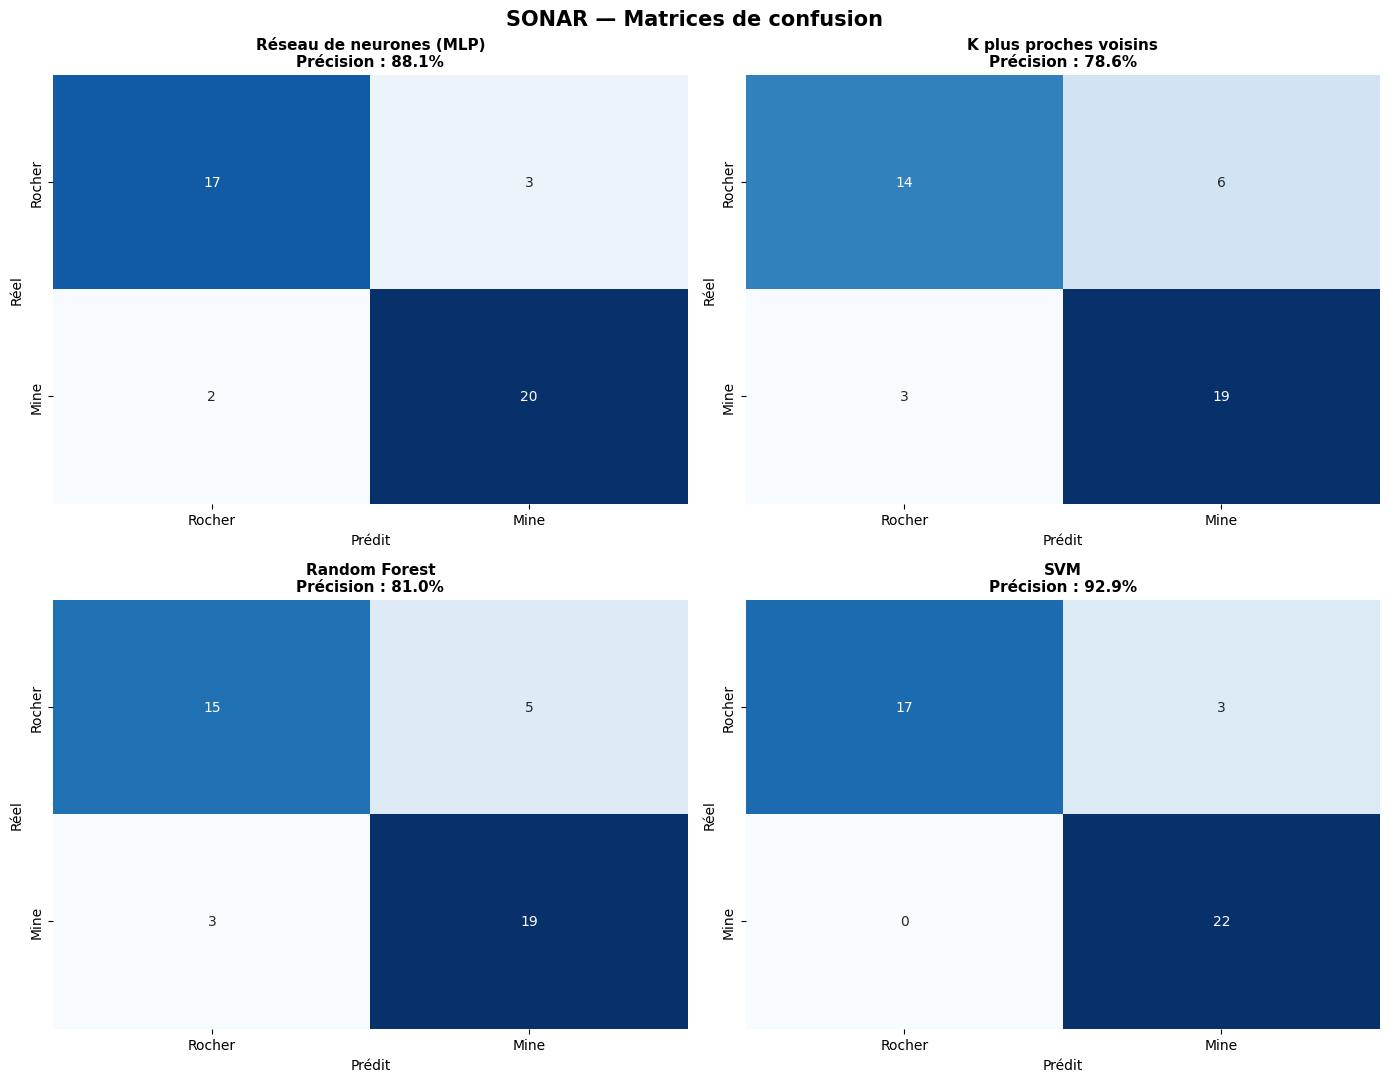

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('SONAR — Matrices de confusion', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, (nom, res) in enumerate(resultats.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Rocher', 'Mine'],
                yticklabels=['Rocher', 'Mine'],
                ax=axes[i], cbar=False)
    axes[i].set_title(f"{nom}\nPrécision : {res['acc']*100:.1f}%",
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.tight_layout()
plt.show()

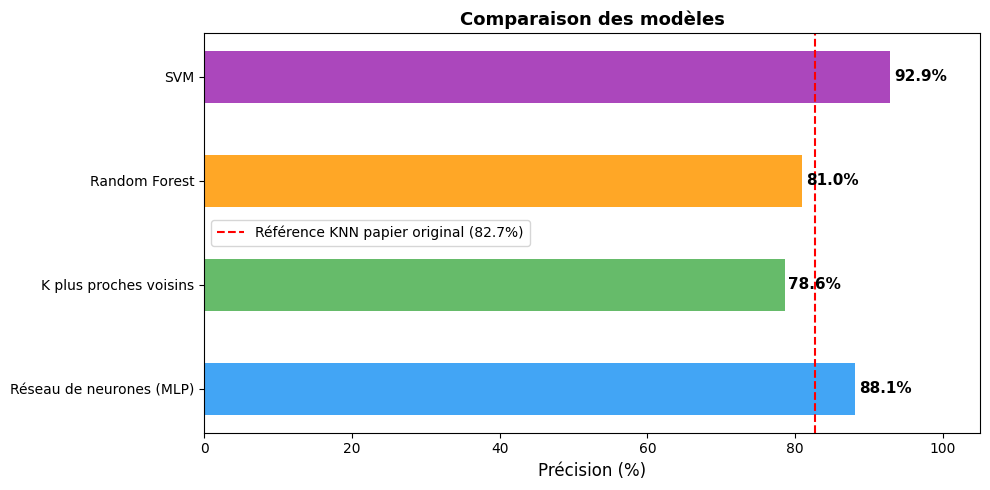

In [9]:
# Comparaison des précisions
noms = list(resultats.keys())
accs = [v['acc'] * 100 for v in resultats.values()]
colors = ['#42A5F5', '#66BB6A', '#FFA726', '#AB47BC']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(noms, accs, color=colors, height=0.5)
ax.set_xlim(0, 105)
ax.set_xlabel('Précision (%)', fontsize=12)
ax.set_title('Comparaison des modèles', fontsize=13, fontweight='bold')
ax.axvline(82.7, color='red', linestyle='--', linewidth=1.5,
           label='Référence KNN papier original (82.7%)')
ax.legend()

for bar, acc in zip(bars, accs):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.1f}%', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## Étape 8 — Validation croisée (Cross-Validation)

In [10]:
print("Validation croisée (5 folds) sur l'ensemble complet :\n")

X_scaled = scaler.fit_transform(X)

for nom, modele in modeles.items():
    scores = cross_val_score(modele, X_scaled, y, cv=5, scoring='accuracy')
    print(f"{nom:<35} Moy: {scores.mean()*100:.1f}%  ±{scores.std()*100:.1f}%")

Validation croisée (5 folds) sur l'ensemble complet :

Réseau de neurones (MLP)            Moy: 70.2%  ±10.6%
K plus proches voisins              Moy: 56.7%  ±14.9%
Random Forest                       Moy: 66.4%  ±7.0%
SVM                                 Moy: 63.9%  ±9.5%


## Conclusion

| Modèle | Précision test |
|--------|---------------|
| Réseau de neurones (MLP) | voir résultats |
| K plus proches voisins | voir résultats |
| Random Forest | voir résultats |
| SVM | voir résultats |

**Référence du papier original** : 82.7% avec KNN, jusqu'à **90.4%** avec un réseau de neurones (angle-dépendant, 12 unités cachées).
